# Box plot with whiskies

In [ ]:
import pandas as pd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib import cbook
import seaborn as sns
from scipy import stats
from pathlib import Path
import numpy as np
import os

from my_utils.plotting import set_font

In [8]:
PROJECT_ROOT = Path(r"C:\Users\Eduard Haiman\Downloads") 

In [9]:
path = PROJECT_ROOT / r"Hybrid Places 2026 Data.csv"
data = pd.read_csv(path)
data

,Value,Confidence,Capability,Templates
0,3,3,2,5
1,4,4,5,5
2,5,5,4,5
3,4,4,5,5
4,4,4,5,4
5,4,2,4,2
6,4,4,5,5
7,3,3,3,4
8,4,4,5,5


In [10]:
columns_list = [
    'Value',
    'Confidence',
    'Capability',
    'Templates',
]

group = 'Groups'
df = pd.DataFrame({
    'Score': pd.concat([data[col] for col in columns_list]),
    'Questions': pd.concat([
        pd.Series([col] * len(data)) for col in columns_list
    ]),
    #group : pd.concat([data[group]] * len(columns_list))
    })
df[:12]

,Score,Questions
0,3,Value
1,4,Value
2,5,Value
3,4,Value
4,4,Value
5,4,Value
6,4,Value
7,3,Value
8,4,Value
0,3,Confidence


Setting font style: Inter 24pt
 - font.family      : Inter 24pt
 - font.size        : 12
 - axes.titlesize   : 18
 - axes.labelsize   : 14
 - legend.fontsize  : 14
 - xtick.labelsize  : 12
 - ytick.labelsize  : 12
 - figure.titlesize : 18
Font Configuration
 - font.family      : Inter 24pt
 - font.size        :         12
 - axes.titlesize   :         18
 - axes.labelsize   :         14
 - legend.fontsize  :         14
 - xtick.labelsize  :         12
 - ytick.labelsize  :         12
 - figure.titlesize :         18


C:\Users\Eduard Haiman\AppData\Local\Temp\ipykernel_41908\4157453973.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=group, fontsize=12)


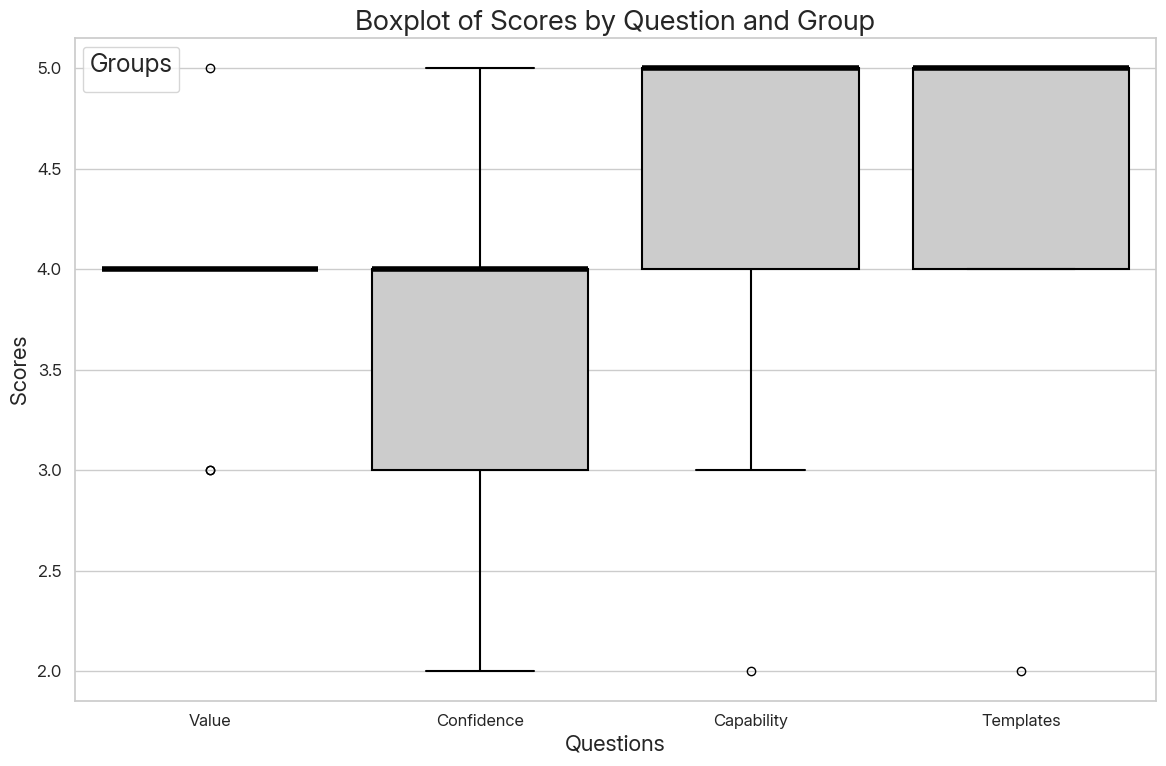

In [11]:
# Rebuild the font cache (run this once after installing the font)
set_font(print_info=True)  # Call the function to set the font
#fm.fontManager.addfont(r"../data/fonts/Inter_24pt-Regular.ttf")
#Set the EXACT name found in your verification step
target_font = 'Inter 24pt'
fig, ax = plt.subplots(figsize=(12, 8)) #
sns.set_theme(
    rc={'font.family': target_font},
    font_scale=1.5, # Set font scale 
    style="whitegrid" # Set style to whitegrid
    ) 
sns.boxplot(data=df, x='Questions', y='Score',
            #hue=group, palette='pastel', 
            color=".8", linecolor="#000", linewidth=1.5,
            medianprops={'color': 'black', 'linewidth': 4},
            )
plt.title('Boxplot of Scores by Question and Group', fontsize=20)
plt.xlabel('Questions', fontsize=16)
plt.ylabel('Scores', fontsize=16)
plt.legend(title=group, fontsize=12)
plt.tight_layout()
#plt.savefig('output/groups_vs_questions_boxplot.png', dpi=300)
plt.show()

In [12]:
criteria_list = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
pvalue_stat = []
for criteria in criteria_list:
    set_a = df['Score'][(df[group] == 'A')&(df['Questions'] == criteria)]
    set_b = df['Score'][(df[group] == 'B')&(df['Questions'] == criteria)]
    p_value_ttest = stats.ttest_ind(set_a, set_b).pvalue
    stat, p_value_mannwhitney = stats.mannwhitneyu(set_a, set_b, alternative='two-sided')
    dic = {
        "Criteria": criteria,
        "t-test p-value": f"{p_value_ttest:.6f}",
        "Mann-Whitney p-value (two-sided)": f"{p_value_mannwhitney:.6f}",
        "Mann-Whitney U statistic (two-sided)": f"{stat:.6f}"
    }
    pvalue_stat.append(dic)
pvalue_stat
pvalue_df = pd.DataFrame(pvalue_stat)
pvalue_df.to_csv("output/groups_vs_questions_pvalue_statistics.csv", index=False)
pvalue_df

KeyError: 'Groups'

In [ ]:
''' Calculate boxplot statistics for random vs trained for each criteria '''
'''WITHOUT GROUPS'''
stats_list = []
def append_stats(stats, column, group):
    stats_list.append({
        'Criteria': column,
        'Median': stats[0]['med'],
        'IQR': stats[0]['iqr'],
        'Whisker Low': stats[0]['whislo'],
        'Whisker High': stats[0]['whishi'],
    })

for column in columns_list:
    set = df['Score'][(df['Questions'] == column)]
    set_stats = cbook.boxplot_stats(set)
    append_stats(set_stats, column, 'A')
statistics = pd.DataFrame(stats_list)
#statistics.to_csv("output/groups_by_questions_statistics.csv", index=False)
statistics

,Criteria,Median,IQR,Whisker Low,Whisker High
0,Value,4.0,0.0,4,4
1,Confidence,4.0,1.0,2,5
2,Capability,5.0,1.0,3,5
3,Templates,5.0,1.0,4,5


In [ ]:
''' Calculate boxplot statistics for random vs trained for each criteria '''
stats_list = []
def append_stats(stats, column, group):
    stats_list.append({
        'Criteria': column,
        'Group': group,
        'Median': stats[0]['med'],
        'IQR': stats[0]['iqr'],
        'Whisker Low': stats[0]['whislo'],
        'Whisker High': stats[0]['whishi'],
    })

for column in columns_list:
    set_a = df['Score'][(df['Questions'] == column)&(df[group] == 'A')]
    set_b = df['Score'][(df['Questions'] == column)&(df[group] == 'B')]
    set_a_stats = cbook.boxplot_stats(set_a)
    set_b_stats = cbook.boxplot_stats(set_b)
    append_stats(set_a_stats, column, 'A')
    append_stats(set_b_stats, column, 'B')
statistics = pd.DataFrame(stats_list)
#statistics.to_csv("output/groups_by_questions_statistics.csv", index=False)
statistics

KeyError: 'Groups'

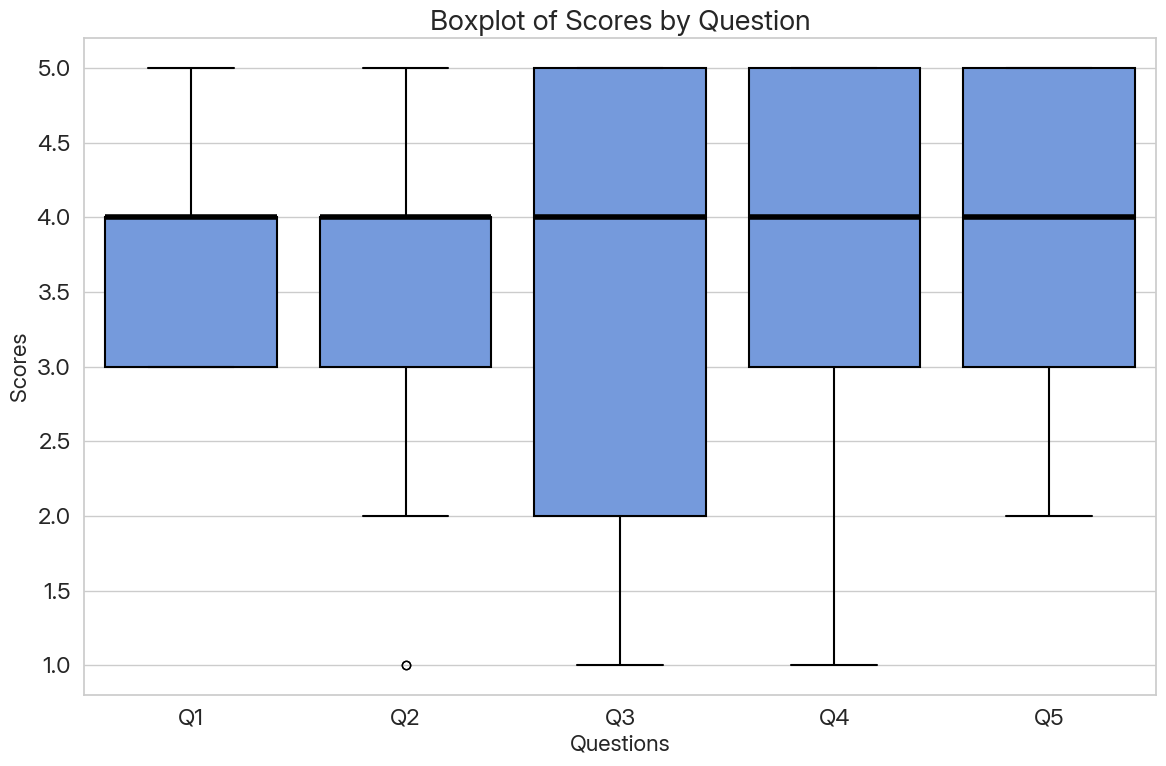

In [ ]:
# Rebuild the font cache (run this once after installing the font)
fm.fontManager.addfont(r"fonts/Inter_24pt-Regular.ttf")
#Set the EXACT name found in your verification step
target_font = 'Inter 24pt'
fig, ax = plt.subplots(figsize=(12, 8)) #
sns.set_theme(
    rc={'font.family': target_font},
    font_scale=1.5, # Set font scale 
    style="whitegrid" # Set style to whitegrid
    ) 
sns.boxplot(data=df, x='Questions', y='Score', 
            color="cornflowerblue", linecolor="#000", linewidth=1.5,
            medianprops={'color': 'black', 'linewidth': 4}
            )
plt.title('Boxplot of Scores by Question', fontsize=20)
plt.xlabel('Questions', fontsize=16)
plt.ylabel('Scores', fontsize=16)
plt.tight_layout()
plt.savefig('output/full_set_by_questions_boxplot.png', dpi=300)
plt.show()

In [ ]:
''' Calculate boxplot statistics for full set for each criteria '''
stats_list = []
def append_stats(stats, column):
    stats_list.append({
        'Criteria': column,
        'Median': stats[0]['med'],
        'IQR': stats[0]['iqr'],
        'Whisker Low': stats[0]['whislo'],
        'Whisker High': stats[0]['whishi'],
    })

for column in criteria_list:
    set_full = df['Score'][(df['Questions'] == column)]
    set_full_stats = cbook.boxplot_stats(set_full)
    append_stats(set_full_stats, column)
statistics = pd.DataFrame(stats_list)
statistics.to_csv("output/full_set_by_questions_statistics.csv", index=False)
statistics

,Criteria,Median,IQR,Whisker Low,Whisker High
0,Q1,4.0,1.0,3,5
1,Q2,4.0,1.0,2,5
2,Q3,4.0,3.0,1,5
3,Q4,4.0,2.0,1,5
4,Q5,4.0,2.0,2,5


In [ ]:
from scipy.stats import mannwhitneyu

# Sample data
group_a = df[(df[group] == 'A') & (df['Questions'] == 'Q5')]['Score'].tolist()
group_b = df[(df[group] == 'B') & (df['Questions'] == 'Q5')]['Score'].tolist()
print(f"Group A: {len(group_a)}, Group B: {len(group_b)}")

alternatives = ['two-sided', 'less', 'greater']
for alt in alternatives:
    print(f"\nAlternative: {alt}")
    # Perform two-sided Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_a, group_b, alternative=alt)
    print(f"U Statistic: {stat}")
    print(f"P-value: {p_value}")

    # Interpret the results
    alpha = 0.05
    if p_value < alpha:
        print("Statistically significant difference (Reject H0)")
    else:
        print("No significant difference (Fail to reject H0)")

Group A: 20, Group B: 5

Alternative: two-sided
U Statistic: 14.5
P-value: 0.013832804328629381
Statistically significant difference (Reject H0)

Alternative: less
U Statistic: 14.5
P-value: 0.006916402164314691
Statistically significant difference (Reject H0)

Alternative: greater
U Statistic: 14.5
P-value: 0.9943277939703155
No significant difference (Fail to reject H0)
